# 01 — EDA: Model Adaptif Perencanaan Ulang

**Dataset Combined:**
- `gym_members_exercise_tracking.csv` (973 baris, real)
- `gym_members_exercise_tracking_synthetic_data.csv` (1,800 baris, synthetic)
- **Combined: 2,773 baris** — sama dengan Model 1

**Tujuan:**
- Eksplorasi data untuk simulasi `weekly_score` per user
- Distribusi BMI, Experience_Level, frequency (proxy adherence)
- Simulate `weekly_score` (0-100) berbasis user profile
- Simulate `weight_diff_kg` per week (target outcome variable)

**Riset acuan:**
- DIAMANTE Trial (JMIR 2024): reward = compliance + progress - dropout

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

sns.set_theme(style='darkgrid')
os.makedirs('output/eda', exist_ok=True)
np.random.seed(42)

# Combined dataset (sama dengan Model 1)
PATH_REAL      = '../../dataset/Model_rekomendasi_Pelatihan/gym_member_exercise_dataset/gym_members_exercise_tracking.csv'
PATH_SYNTHETIC = '../../dataset/Model_Adaptif_Perencanaan_Ulang/Fitness Tracker Dataset/gym_members_exercise_tracking_synthetic_data.csv'

df_real      = pd.read_csv(PATH_REAL)
df_synthetic = pd.read_csv(PATH_SYNTHETIC)
df_real['data_source'] = 'real'
df_synthetic['data_source'] = 'synthetic'
df = pd.concat([df_real, df_synthetic], ignore_index=True)
print(f'Combined: {df.shape}')

Combined: (2773, 16)


In [2]:
df.info()
print('\nMissing:', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2763 non-null   float64
 1   Gender                         2702 non-null   object 
 2   Weight (kg)                    2751 non-null   float64
 3   Height (m)                     2747 non-null   float64
 4   Max_BPM                        2752 non-null   object 
 5   Avg_BPM                        2743 non-null   float64
 6   Resting_BPM                    2754 non-null   float64
 7   Session_Duration (hours)       2750 non-null   float64
 8   Calories_Burned                2750 non-null   float64
 9   Workout_Type                   2712 non-null   object 
 10  Fat_Percentage                 2757 non-null   float64
 11  Water_Intake (liters)          2749 non-null   float64
 12  Workout_Frequency (days/week)  2715 non-null   f

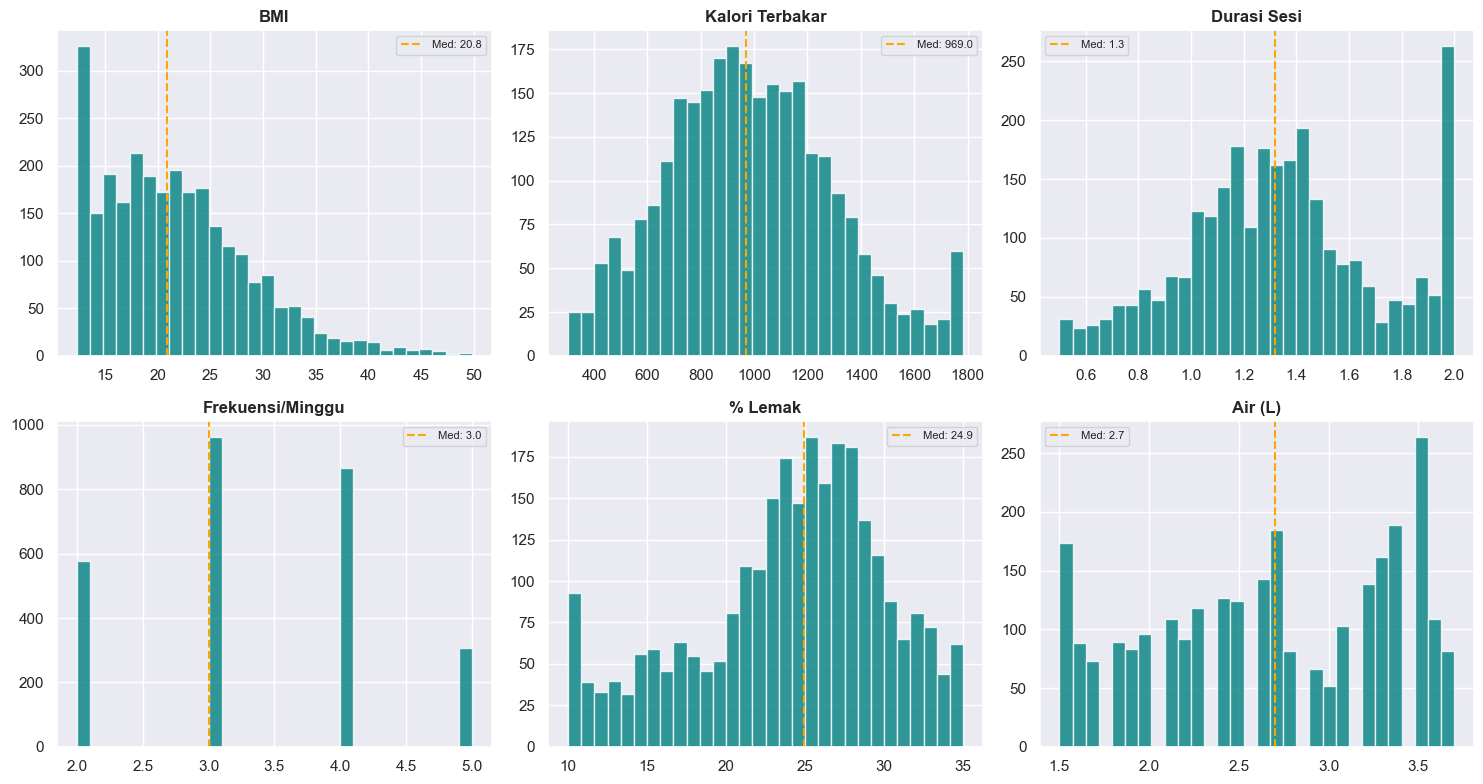

In [3]:
# ── Distribusi Fitur Utama ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plots = [
    ('BMI', 'BMI'), ('Calories_Burned', 'Kalori Terbakar'),
    ('Session_Duration (hours)', 'Durasi Sesi'),
    ('Workout_Frequency (days/week)', 'Frekuensi/Minggu'),
    ('Fat_Percentage', '% Lemak'), ('Water_Intake (liters)', 'Air (L)'),
]
for ax, (col, label) in zip(axes.flatten(), plots):
    if col in df.columns:
        df[col].hist(bins=30, ax=ax, color='teal', edgecolor='white', alpha=0.8)
        ax.set_title(label, fontweight='bold')
        ax.axvline(df[col].median(), color='orange', linestyle='--',
                   label=f'Med: {df[col].median():.1f}')
        ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('output/eda/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

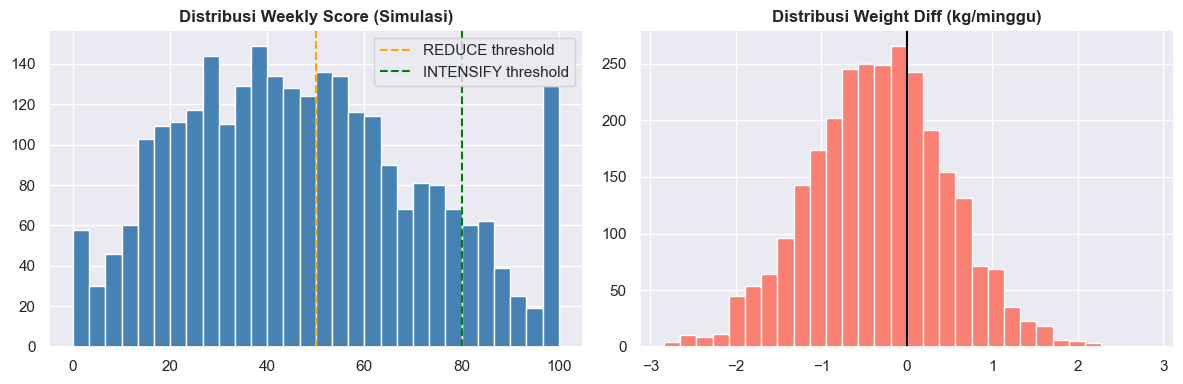

REDUCE (<50):    1552 (56.0%)
MAINTAIN (50-80): 887
INTENSIFY (>80):  334


In [4]:
# ── Simulasi Weekly Score (DIAMANTE pattern: compliance + progress) ──
def simulate_weekly_score(row):
    """Simulate weekly score 0-100 berdasarkan profil user.
    Higher Experience_Level + lower BMI → higher score baseline."""
    base = row['Experience_Level'] * 25  # 25/50/75 for beg/int/adv
    bmi_penalty = max(0, (row['BMI'] - 25) * 1.5)  # Lebih berat = harder
    freq_bonus = (row['Workout_Frequency (days/week)'] - 3) * 5
    noise = np.random.normal(0, 10)
    return max(0, min(100, base - bmi_penalty + freq_bonus + noise))

df['simulated_weekly_score'] = df.apply(simulate_weekly_score, axis=1)
df['simulated_weight_diff'] = np.random.normal(-0.3, 0.8, len(df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['simulated_weekly_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(50, color='orange', linestyle='--', label='REDUCE threshold')
axes[0].axvline(80, color='green', linestyle='--', label='INTENSIFY threshold')
axes[0].set_title('Distribusi Weekly Score (Simulasi)', fontweight='bold')
axes[0].legend()

axes[1].hist(df['simulated_weight_diff'], bins=30, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black')
axes[1].set_title('Distribusi Weight Diff (kg/minggu)', fontweight='bold')

plt.tight_layout()
plt.savefig('output/eda/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'REDUCE (<50):    {(df["simulated_weekly_score"] < 50).sum()} ({(df["simulated_weekly_score"] < 50).mean()*100:.1f}%)')
print(f'MAINTAIN (50-80): {((df["simulated_weekly_score"] >= 50) & (df["simulated_weekly_score"] <= 80)).sum()}')
print(f'INTENSIFY (>80):  {(df["simulated_weekly_score"] > 80).sum()}')

In [5]:
# ── Simpan ──
df.to_csv('output/eda/synthetic_with_score.csv', index=False)

summary = {
    'n_rows': len(df),
    'real_count': len(df_real),
    'synthetic_count': len(df_synthetic),
    'score_mean': round(float(df['simulated_weekly_score'].mean()), 2),
    'score_std': round(float(df['simulated_weekly_score'].std()), 2),
    'reduce_pct': round((df['simulated_weekly_score'] < 50).mean() * 100, 1),
    'maintain_pct': round(((df['simulated_weekly_score'] >= 50) & (df['simulated_weekly_score'] <= 80)).mean() * 100, 1),
    'intensify_pct': round((df['simulated_weekly_score'] > 80).mean() * 100, 1),
}
with open('output/eda/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ EDA selesai.')
print(json.dumps(summary, indent=2))

✅ EDA selesai.
{
  "n_rows": 2773,
  "real_count": 973,
  "synthetic_count": 1800,
  "score_mean": 47.46,
  "score_std": 24.97,
  "reduce_pct": 56.0,
  "maintain_pct": 32.0,
  "intensify_pct": 12.0
}
